# GISLR — Sentence baselines: existing isolated-sign models on continuous signing

**What this notebook does.** Diagnostic, not a pipeline stage (TODO §12.2).
It asks how well today's isolated-sign models recognize a *sequence* of
signs, using the reset-on-accept loop the user specified. At every frame,
the model gives a confidence over every gloss since the last reset; once one
gloss stays over a threshold, it is emitted and the model's state resets.
No training. The numbers here are what the continuous model (§12.3) has to
beat.

**Data.** GISLR-Sentences v1 (§12.1), resolved by
`sb.core.paths.gislr_sentences_dir`: the Kaggle dataset
`bracu23101281/gislr-sentences` via kagglehub, falling back to the local
build until that is published. The setup cell prints which copy was used.

**Models** (no training, all already on disk or on the artifact remote):

| name | checkpoint | input | selected on |
|---|---|---|---|
| `gru_reg` | registry `1789559734` (best registry run, 75.2%) | ME-132 xy | `test.csv` (the canonical val), so it has a small selection advantage here |
| `gru` `lstm` `cnn` `dnn` `bilstm` | `gislr.1.models.five-arch-benchmark.ipynb` | ME-126 xy | an internal val carved from `train.csv` |

**Decoding modes**

| mode | what | models |
|---|---|---|
| **B1 oracle** | fresh state at each true sign start, prediction read at the true sign end. The upper bound; its per-clip predictions must reproduce the isolated test predictions (§3 parity) | all |
| **B2 reset-on-accept** | the whole stream, null frames included. Top gloss `>= tau` for `hold` frames → emit + reset | `gru_reg` `gru` `lstm` |
| **B3 no reset** | the same trigger, state never reset (the contamination baseline) | `gru_reg` `gru` `lstm` |
| **B4 sliding window** | classify every `win`-frame window (stride 2); a run of `min_run` windows agreeing at `>= tau` emits once. The only streaming option for stateless/offline models | `gru` `cnn` `dnn` `bilstm` |

Every mode is scored raw and with consecutive duplicates collapsed (a long
sign accepted repeatedly under reset-on-accept is a real failure mode, seen
in the first real sequences). Collapsing costs the rare genuine repeat
(`WHO WHO`).

**Metrics** (`sb.recognize.sequences.metrics`)
- **Gloss error rate (GER)** = (substitutions + deletions + insertions) / reference glosses, by edit alignment.
- Sentence accuracy.
- Commit latency: accept frame minus the true sign's last frame, over correctly aligned signs. Negative means it committed before the sign ended.
- Where emissions and insertions land: sign / transition / rest, as insertions per 1,000 frames of each kind.
- Split comparisons: `sentence` vs `control` (these models have no language prior, so the two should match), and with-null vs **hard-cut** (null frames dropped).

**No threshold is chosen on the data it is reported on.** τ/hold/win/min_run
are swept on **5 selection signers** (seeded) of the `sentence` split; every
reported number uses the **other 16 signers**.

**Artifacts** (`data/cache/gislr/sentence_baselines/`):

| path | content |
|---|---|
| `features/<key>/` | stream model inputs per landmark set (content-addressed by rows, coords and dataset build hashes) |
| `results/b1_<model>.json` | oracle per-sequence predictions |
| `results/sweep_<model>_<mode>.json` | selection-signer aggregates for every decoder setting |
| `results/final.json`, `results/final_table.csv` | chosen settings scored on the evaluation signers |
| `results/assets/*.png` | figures |

**Resumable.** Every results file is written atomically, and a cell skips
work whose file already exists. Delete a file to recompute it.
`LIMIT_PER_GROUP` makes a quick smoke run into `results_smoke/` instead.

**Known caveats carried in:** clips are fed at native length, while
isolated training subsampled the ~8% of clips over 128 frames (TODO §11.1).
v1 rest frames have NaN hands, so rest is easier than real rest; it is
always reported apart from transitions.

## Setup

In [1]:
# ============================================================
# Imports, config, dataset, signer split, shared loaders
# ============================================================
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from sb.core.paths import CACHE_DIR, EXPERIMENTS_DIR, MODELS_DIR, gislr_dir, gislr_sentences_dir
from sb.recognize import streaming as S
from sb.recognize.sequences import baselines as B
from sb.recognize.sequences import metrics as M
from sb.recognize.sequences.compose import FRAME_KINDS, SIGN

CONFIG_DIR = EXPERIMENTS_DIR / "recognition" / "configs"
CONFIG = json.loads((CONFIG_DIR / "gislr.sentence-baselines.json").read_text(encoding="utf-8"))
FIVE_ARCH_CONFIG = json.loads((CONFIG_DIR / CONFIG["five_arch_config"]).read_text(encoding="utf-8"))

LIMIT_PER_GROUP = None  # e.g. 20 -> quick smoke run (sequences per split x signer group), written to results_smoke/

DATASET_ROOT = gislr_sentences_dir(CONFIG["dataset_version"])
OUT = CACHE_DIR / "gislr" / "sentence_baselines" / ("results" if LIMIT_PER_GROUP is None else "results_smoke")
ASSETS = OUT / "assets"
ASSETS.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(False)

LABEL_MAP = json.loads((DATASET_ROOT / "sign_to_prediction_index_map.json").read_text(encoding="utf-8"))
N_CLASSES = len(LABEL_MAP)
SEQ = pd.read_csv(DATASET_ROOT / "sequences.csv", keep_default_na=False)
SEQ["row"] = np.arange(len(SEQ))  # row index into the feature caches
SELECT, EVAL = B.signer_split(SEQ["participant_id"], CONFIG["n_selection_signers"], CONFIG["seed"])
SEQ["group"] = np.where(SEQ["participant_id"].isin(SELECT), "select", "eval")
if LIMIT_PER_GROUP is not None:
    SEQ = SEQ.groupby(["kind", "group"], group_keys=False).head(LIMIT_PER_GROUP)


def seq_arrays(r) -> tuple[np.ndarray, np.ndarray]:
    """(labels, segments) of one sequences.csv row."""
    labels = np.array(r["labels"].split(), dtype=np.int64)
    seg = np.stack([np.array(r["starts"].split(), int), np.array(r["ends"].split(), int)], 1)
    return labels, seg


def hard_cut(x: np.ndarray, kinds: np.ndarray, seg: np.ndarray):
    """Drop every null frame: the back-to-back concatenation of the clips,
    with segments remapped."""
    keep = kinds == SIGN
    newpos = np.cumsum(keep) - 1
    seg2 = np.stack([newpos[seg[:, 0]], newpos[seg[:, 1] - 1] + 1], 1)
    return x[keep], kinds[keep], seg2


def frame_totals(rows, feats) -> dict:
    kinds = np.concatenate([feats.kind(i) for i in rows]) if len(rows) else np.array([], np.uint8)
    return {name: int((kinds == k).sum()) for k, name in FRAME_KINDS.items()}


def write_json(path: Path, obj) -> None:
    tmp = path.with_suffix(".tmp")
    tmp.write_text(json.dumps(obj, indent=1), encoding="utf-8")
    os.replace(tmp, path)


_MODELS, _FEATS = {}, {}


def get_model(name: str) -> B.LoadedModel:
    if name not in _MODELS:
        spec = CONFIG["models"][name]
        if spec["source"] == "registry":
            m = B.load_registry_model(MODELS_DIR / str(spec["run_id"]), N_CLASSES, DEVICE)
            m.name = name
        else:
            m = B.load_five_arch_model(name, CACHE_DIR / CONFIG["five_arch_root"], FIVE_ARCH_CONFIG,
                                       N_CLASSES, DEVICE)
        _MODELS[name] = m
    return _MODELS[name]


def get_features(m: B.LoadedModel) -> B.StreamFeatures:
    """Features for the FULL sequences.csv (row = SEQ['row']), built once per landmark set."""
    key = B.StreamFeatures.key(DATASET_ROOT, m.rows, m.coords)
    if key not in _FEATS:
        full = pd.read_csv(DATASET_ROOT / "sequences.csv", keep_default_na=False)
        bar = tqdm(total=len(full), desc=f"features {len(m.rows)} rows/{m.coords}")
        _FEATS[key] = B.StreamFeatures.build(DATASET_ROOT, full, m.rows, m.coords,
                                             progress=lambda d, t: bar.update(d - bar.n))
        bar.close()
    return _FEATS[key]


def x_of(feats, i) -> torch.Tensor:
    return torch.from_numpy(np.ascontiguousarray(feats.x(i)))


print(f"dataset: {DATASET_ROOT}")
print(f"results: {OUT}   device: {DEVICE}")
print(f"selection signers {SELECT}\nevaluation signers ({len(EVAL)}) {EVAL}")
print(SEQ.groupby(["kind", "group"]).size().unstack())

gislr_sentences_dir: kaggle copy unavailable (KaggleApiHTTPError); using the local build C:\Users\user2\repository\data\cache\gislr\sentences\v1
dataset: C:\Users\user2\repository\data\cache\gislr\sentences\v1
results: C:\Users\user2\repository\data\cache\gislr\sentence_baselines\results   device: cuda
selection signers [4718, 28656, 29302, 34503, 36257]
evaluation signers (16) [2044, 16069, 18796, 22343, 25571, 26734, 27610, 30680, 32319, 37055, 37779, 49445, 53618, 55372, 61333, 62590]
group     eval  select
kind                  
control   4639    1472
sentence  5054    1562


## 1. Stream features (built once per landmark set)

The same per-frame transform the models were trained on (row subset, xy,
NaN → 0), applied to every full sequence. Two landmark sets are needed:
ME-126 for the five-arch arms and ME-132 for `gru_reg`. Each is about 2 GB
in RAM. It is cached under a content key, so this cell is a no-op after the
first run.

In [2]:
# ============================================================
# Build / load the feature caches for every configured model
# ============================================================
for name in CONFIG["models"]:
    m = get_model(name)
    f = get_features(m)
    print(f"{name:<8} {m.coords} {len(m.rows)} landmarks -> feature_dim {f.data.shape[1]}, "
          f"{len(f)} sequences, {f.data.shape[0]:,} frames  ({m.note})")

features 132 rows/xy:   0%|          | 0/12727 [00:00<?, ?it/s]

gru_reg  xy 132 landmarks -> feature_dim 264, 12727 sequences, 2,166,416 frames  (registry run; checkpoint selected on test.csv (the canonical val set))


features 126 rows/xy:   0%|          | 0/12727 [00:00<?, ?it/s]

gru      xy 126 landmarks -> feature_dim 252, 12727 sequences, 2,166,416 frames  (five-arch benchmark; selected on an internal val carved from train.csv)
lstm     xy 126 landmarks -> feature_dim 252, 12727 sequences, 2,166,416 frames  (five-arch benchmark; selected on an internal val carved from train.csv)
cnn      xy 126 landmarks -> feature_dim 252, 12727 sequences, 2,166,416 frames  (five-arch benchmark; selected on an internal val carved from train.csv)
dnn      xy 126 landmarks -> feature_dim 252, 12727 sequences, 2,166,416 frames  (five-arch benchmark; selected on an internal val carved from train.csv)
bilstm   xy 126 landmarks -> feature_dim 252, 12727 sequences, 2,166,416 frames  (five-arch benchmark; selected on an internal val carved from train.csv)


## 2. Parity: the fast decoder is the live loop

Two checks before any number is trusted:
1. `first_accept` (the vectorized trigger that makes a sweep over thousands
   of sequences feasible) against the original `AcceptTrigger` fed row by
   row, for every swept `(tau, hold)`, on real `gru` streams.
2. `decode_stream` (batch forwards restarted at each accept) against the
   real live loop: `RecurrentSession.step` frame by frame + `AcceptTrigger`
   + `reset()` on accept, on CPU, with and without reset.

In [3]:
# ============================================================
# first_accept == AcceptTrigger on real per-frame probabilities
# ============================================================
N_PARITY = 40  # sequences

m = get_model("gru")
feats = get_features(m)
rows = SEQ["row"].to_numpy()[:N_PARITY]
mismatch = total = 0
for i in tqdm(rows, desc="trigger parity"):
    p = S.per_frame_probs(m.model, m.arch, x_of(feats, i))
    for tau in CONFIG["reset_decode"]["tau"]:
        for hold in CONFIG["reset_decode"]["hold"]:
            trig, ref = S.AcceptTrigger(tau, hold), None
            for k, row in enumerate(p):
                c = trig.update(row)
                if c is not None:
                    ref = (k, c)
                    break
            mismatch += ref != S.first_accept(p, tau, hold)
            total += 1
print(f"first_accept vs AcceptTrigger: {mismatch} mismatches / {total} (sequence, tau, hold) cases")
assert mismatch == 0

trigger parity:   0%|          | 0/40 [00:00<?, ?it/s]

first_accept vs AcceptTrigger: 0 mismatches / 960 (sequence, tau, hold) cases


In [4]:
# ============================================================
# decode_stream == the real live loop (RecurrentSession.step + AcceptTrigger)
# ============================================================
N_LIVE = 10  # sequences; CPU, where step-wise and batch agree to 1e-6 (TODO §11.1)
LIVE_SETTINGS = [(0.5, 3), (0.7, 5), (0.9, 2)]

cpu = torch.device("cpu")
mismatch = total = 0
for name in ("gru", "lstm"):
    m = get_model(name)
    model_cpu = B.load_five_arch_model(name, CACHE_DIR / CONFIG["five_arch_root"], FIVE_ARCH_CONFIG, N_CLASSES, cpu)
    feats = get_features(m)
    for i in SEQ["row"].to_numpy()[:N_LIVE]:
        x = x_of(feats, i)
        for tau, hold in LIVE_SETTINGS:
            for reset in (True, False):
                sess, trig, live = S.RecurrentSession(model_cpu.model, name, cpu), S.AcceptTrigger(tau, hold), []
                for t in range(len(x)):
                    c = trig.update(sess.step(x[t]))
                    if c is not None:
                        live.append((c, t))
                        if reset:
                            sess.reset()
                fast = [(c, t) for c, t, _ in S.decode_stream(model_cpu.model, name, x, tau, hold, reset=reset)]
                mismatch += live != fast
                total += 1
print(f"live loop vs decode_stream: {mismatch} mismatches / {total} (model, sequence, tau, hold, reset) cases")
assert mismatch == 0

live loop vs decode_stream: 0 mismatches / 120 (model, sequence, tau, hold, reset) cases


## 3. B1: oracle segmentation (+ parity with the isolated predictions)

Every model: a fresh state per true segment, and the model's own whole-clip
readout (last frame; softmax-averaged over frames for `dnn`). Run on every
sequence of both splits.

**Parity check.** The `control` split uses every test clip exactly once, so
B1 on it re-predicts each clip in isolation. For clips of ≤ 128 frames
(where isolated evaluation did not subsample), B1 must agree with the saved
isolated predictions. A mismatch would mean the stream features or the
model loading differ from how the model was evaluated.

In [5]:
# ============================================================
# B1 oracle predictions for every model (cached per model)
# ============================================================
for name in CONFIG["models"]:
    path = OUT / f"b1_{name}.json"
    if path.exists():
        continue
    m = get_model(name)
    feats = get_features(m)
    preds = {}
    for _, r in tqdm(SEQ.iterrows(), total=len(SEQ), desc=f"B1 {name}"):
        x = x_of(feats, r["row"])
        _, seg = seq_arrays(r)
        preds[r["seq_id"]] = [int(S.clip_probs(m.model, m.arch, x[s:e]).argmax()) for s, e in seg]
    write_json(path, preds)
print("B1 cached:", sorted(p.name for p in OUT.glob("b1_*.json")))

B1 gru_reg:   0%|          | 0/12727 [00:00<?, ?it/s]

B1 gru:   0%|          | 0/12727 [00:00<?, ?it/s]

B1 lstm:   0%|          | 0/12727 [00:00<?, ?it/s]

B1 cnn:   0%|          | 0/12727 [00:00<?, ?it/s]

B1 dnn:   0%|          | 0/12727 [00:00<?, ?it/s]

B1 bilstm:   0%|          | 0/12727 [00:00<?, ?it/s]

B1 cached: ['b1_bilstm.json', 'b1_cnn.json', 'b1_dnn.json', 'b1_gru.json', 'b1_gru_reg.json', 'b1_lstm.json']


In [6]:
# ============================================================
# B1 parity vs isolated test predictions (control split, clips <= 128 frames)
# ============================================================
test = pd.read_csv(gislr_dir() / "test.csv")
row_of_uid = dict(zip(test["uid"], range(len(test))))
iso = {}
for name, spec in CONFIG["models"].items():
    if spec["source"] == "registry":
        iso[name] = np.load(MODELS_DIR / str(spec["run_id"]) / "assets" / "val_predictions.npz")["preds"]
    else:
        iso[name] = np.load(CACHE_DIR / CONFIG["five_arch_root"] / name / "test_predictions.npz")["probs"].argmax(1)

ctrl = SEQ[SEQ.kind == "control"]
rows_out = []
for name in CONFIG["models"]:
    b1 = json.loads((OUT / f"b1_{name}.json").read_text())
    agree = n = 0
    for _, r in ctrl.iterrows():
        _, seg = seq_arrays(r)
        for uid, (s, e), p in zip(r["source_uids"].split(), seg, b1[r["seq_id"]]):
            if e - s <= CONFIG["parity_max_frames"]:
                agree += p == iso[name][row_of_uid[uid]]
                n += 1
    rows_out.append({"model": name, "clips": n, "agreement": agree / max(n, 1)})
print(pd.DataFrame(rows_out).to_string(index=False))

  model  clips  agreement
gru_reg  17829   0.999888
    gru  17829   0.999663
   lstm  17829   0.999607
    cnn  17829   1.000000
    dnn  17829   1.000000
 bilstm  17829   0.999832


## 4. B2 / B3 sweep: reset-on-accept vs no reset (selection signers only)

Each selection-signer `sentence` sequence is decoded under every
`(tau, hold)`, with and without reset, and scored raw and collapsed. The
per-sequence forward cache means each reset start frame is computed once
per sequence, not once per setting.

In [7]:
# ============================================================
# Sweep decoder settings for the recurrent models
# ============================================================
cfg = CONFIG["reset_decode"]
sel = SEQ[(SEQ.group == "select") & (SEQ.kind == CONFIG["selection_kind"])]
for name in cfg["models"]:
    path = OUT / f"sweep_{name}_reset.json"
    if path.exists():
        continue
    m = get_model(name)
    feats = get_features(m)
    settings = [(reset, tau, hold) for reset in (True, False) for tau in cfg["tau"] for hold in cfg["hold"]]
    scores = {(s, c): [] for s in settings for c in CONFIG["collapse_repeats"]}
    for _, r in tqdm(sel.iterrows(), total=len(sel), desc=f"sweep {name}"):
        x = x_of(feats, r["row"])
        kinds = feats.kind(r["row"])
        labels, seg = seq_arrays(r)
        cache = {}
        for s in settings:
            reset, tau, hold = s
            em = S.decode_stream(m.model, m.arch, x, tau, hold, reset=reset, cache=cache)
            for c in CONFIG["collapse_repeats"]:
                scores[(s, c)].append(M.score_sequence(S.collapse_repeats(em) if c else em, labels, seg, kinds))
    ft = frame_totals(sel["row"], feats)
    out = [{"mode": "B2" if reset else "B3", "tau": tau, "hold": hold, "collapse": c,
            **M.aggregate(sc, ft)} for ((reset, tau, hold), c), sc in scores.items()]
    write_json(path, out)
print("reset sweeps cached:", sorted(p.name for p in OUT.glob("sweep_*_reset.json")))

sweep gru_reg:   0%|          | 0/1562 [00:00<?, ?it/s]

sweep gru:   0%|          | 0/1562 [00:00<?, ?it/s]

sweep lstm:   0%|          | 0/1562 [00:00<?, ?it/s]

reset sweeps cached: ['sweep_gru_reg_reset.json', 'sweep_gru_reset.json', 'sweep_lstm_reset.json']


## 5. B4 sweep: sliding window (selection signers only)

Window probabilities are computed once per `(model, win)` per sequence, and
then every `(tau, min_run)` setting is decoded from them.

In [8]:
# ============================================================
# Sweep sliding-window settings
# ============================================================
cfg = CONFIG["window_decode"]
sel = SEQ[(SEQ.group == "select") & (SEQ.kind == CONFIG["selection_kind"])]
for name in cfg["models"]:
    path = OUT / f"sweep_{name}_window.json"
    if path.exists():
        continue
    m = get_model(name)
    feats = get_features(m)
    settings = [(win, tau, mr) for win in cfg["win"] for tau in cfg["tau"] for mr in cfg["min_run"]]
    scores = {(s, c): [] for s in settings for c in CONFIG["collapse_repeats"]}
    for _, r in tqdm(sel.iterrows(), total=len(sel), desc=f"window sweep {name}"):
        x = x_of(feats, r["row"])
        kinds = feats.kind(r["row"])
        labels, seg = seq_arrays(r)
        for win in cfg["win"]:
            wp, ends = S.window_probs(m.model, m.arch, x, win, cfg["stride"])
            for tau in cfg["tau"]:
                for mr in cfg["min_run"]:
                    em = S.decode_windows(wp, ends, tau, mr)
                    for c in CONFIG["collapse_repeats"]:
                        scores[((win, tau, mr), c)].append(
                            M.score_sequence(S.collapse_repeats(em) if c else em, labels, seg, kinds))
    ft = frame_totals(sel["row"], feats)
    out = [{"mode": "B4", "win": win, "tau": tau, "min_run": mr, "collapse": c, **M.aggregate(sc, ft)}
           for ((win, tau, mr), c), sc in scores.items()]
    write_json(path, out)
print("window sweeps cached:", sorted(p.name for p in OUT.glob("sweep_*_window.json")))

window sweep gru:   0%|          | 0/1562 [00:00<?, ?it/s]

window sweep cnn:   0%|          | 0/1562 [00:00<?, ?it/s]

window sweep dnn:   0%|          | 0/1562 [00:00<?, ?it/s]

window sweep bilstm:   0%|          | 0/1562 [00:00<?, ?it/s]

window sweeps cached: ['sweep_bilstm_window.json', 'sweep_cnn_window.json', 'sweep_dnn_window.json', 'sweep_gru_window.json']


## 6. Final: chosen settings on the evaluation signers

For every `(model, mode, collapse)` the setting with the lowest selection
GER is taken and run on the 16 evaluation signers: both splits, with null
frames and hard-cut. B1 is scored on the same sequences from its cached
predictions.

In [9]:
# ============================================================
# Pick settings on selection signers, score on evaluation signers
# ============================================================
metric = CONFIG["selection_metric"]
chosen = []
for path in sorted(OUT.glob("sweep_*.json")):
    name = path.stem.split("_", 1)[1].rsplit("_", 1)[0]
    sweep = pd.DataFrame(json.loads(path.read_text()))
    for (mode, c), grp in sweep.groupby(["mode", "collapse"]):
        best = grp.sort_values(metric).iloc[0].to_dict()
        chosen.append({"model": name, "mode": mode, "collapse": bool(c),
                       **{k: best[k] for k in ("tau", "hold", "win", "min_run") if k in best and pd.notna(best[k])},
                       "select_" + metric: best[metric]})
chosen = pd.DataFrame(chosen)
print(chosen.to_string(index=False))

ev = SEQ[SEQ.group == "eval"]
final = []
for name in CONFIG["models"]:
    m = get_model(name)
    feats = get_features(m)
    b1 = json.loads((OUT / f"b1_{name}.json").read_text())
    for kind, part in ev.groupby("kind"):
        ft = frame_totals(part["row"], feats)
        sc = []
        for _, r in part.iterrows():
            labels, seg = seq_arrays(r)
            em = [(p, int(e) - 1, 1.0) for p, (_, e) in zip(b1[r["seq_id"]], seg)]
            sc.append(M.score_sequence(em, labels, seg, feats.kind(r["row"])))
        final.append({"model": name, "mode": "B1", "collapse": False, "split": kind, "frames": "with-null",
                      **M.aggregate(sc, ft)})
    for _, ch in chosen[chosen.model == name].iterrows():
        for kind, part in ev.groupby("kind"):
            for frames in ("with-null", "hard-cut"):
                sc, kinds_all = [], []
                for _, r in tqdm(part.iterrows(), total=len(part), leave=False,
                                 desc=f"{name} {ch['mode']} c={ch['collapse']} {kind} {frames}"):
                    x = feats.x(r["row"])
                    kinds = feats.kind(r["row"])
                    labels, seg = seq_arrays(r)
                    if frames == "hard-cut":
                        x, kinds, seg = hard_cut(x, kinds, seg)
                    xt = torch.from_numpy(np.ascontiguousarray(x))
                    if ch["mode"] == "B4":
                        wp, ends = S.window_probs(m.model, m.arch, xt, int(ch["win"]),
                                                  CONFIG["window_decode"]["stride"])
                        em = S.decode_windows(wp, ends, ch["tau"], int(ch["min_run"]))
                    else:
                        em = S.decode_stream(m.model, m.arch, xt, ch["tau"], int(ch["hold"]),
                                             reset=ch["mode"] == "B2")
                    if ch["collapse"]:
                        em = S.collapse_repeats(em)
                    sc.append(M.score_sequence(em, labels, seg, kinds))
                    kinds_all.append(kinds)
                k = np.concatenate(kinds_all)
                ft = {n: int((k == v).sum()) for v, n in FRAME_KINDS.items()}
                final.append({"model": name, "mode": ch["mode"], "collapse": bool(ch["collapse"]),
                              "split": kind, "frames": frames,
                              **{p: ch[p] for p in ("tau", "hold", "win", "min_run") if p in ch and pd.notna(ch[p])},
                              **M.aggregate(sc, ft)})
write_json(OUT / "final.json", {"chosen": chosen.to_dict(orient="records"), "results": final,
                                 "select_signers": SELECT, "eval_signers": EVAL,
                                 "dataset_root": str(DATASET_ROOT)})
print(f"final: {len(final)} rows -> {OUT / 'final.json'}")

  model mode  collapse  tau  win  min_run  select_ger  hold
 bilstm   B4     False  0.7 24.0      3.0    0.645965   NaN
 bilstm   B4      True  0.8 24.0      1.0    0.606537   NaN
    cnn   B4     False  0.8 32.0      3.0    0.721553   NaN
    cnn   B4      True  0.8 32.0      3.0    0.687232   NaN
    dnn   B4     False  0.4 16.0      1.0    0.772829   NaN
    dnn   B4      True  0.4 16.0      1.0    0.755260   NaN
gru_reg   B2     False  0.7  NaN      NaN    0.871502   8.0
gru_reg   B2      True  0.5  NaN      NaN    0.778958   8.0
gru_reg   B3     False  0.9  NaN      NaN    1.159755   8.0
gru_reg   B3      True  0.4  NaN      NaN    0.830031   8.0
    gru   B2     False  0.6  NaN      NaN    0.850051   8.0
    gru   B2      True  0.5  NaN      NaN    0.763841   8.0
    gru   B3     False  0.9  NaN      NaN    1.144842   8.0
    gru   B3      True  0.4  NaN      NaN    0.823085   8.0
    gru   B4     False  0.7 24.0      3.0    0.636159   NaN
    gru   B4      True  0.7 24.0      2.

gru_reg B2 c=False control with-null:   0%|          | 0/4639 [00:00<?, ?it/s]

gru_reg B2 c=False control hard-cut:   0%|          | 0/4639 [00:00<?, ?it/s]

gru_reg B2 c=False sentence with-null:   0%|          | 0/5054 [00:00<?, ?it/s]

gru_reg B2 c=False sentence hard-cut:   0%|          | 0/5054 [00:00<?, ?it/s]

...

bilstm B4 c=True control with-null:   0%|          | 0/4639 [00:00<?, ?it/s]

bilstm B4 c=True control hard-cut:   0%|          | 0/4639 [00:00<?, ?it/s]

bilstm B4 c=True sentence with-null:   0%|          | 0/5054 [00:00<?, ?it/s]

bilstm B4 c=True sentence hard-cut:   0%|          | 0/5054 [00:00<?, ?it/s]

final: 92 rows -> C:\Users\user2\repository\data\cache\gislr\sentence_baselines\results\final.json


## 7. Results

In [10]:
# ============================================================
# Headline table: sentence split, evaluation signers
# ============================================================
res = pd.json_normalize(json.loads((OUT / "final.json").read_text())["results"])
key = ["model", "mode", "collapse"]
main = res[(res.split == "sentence") & (res.frames == "with-null")].set_index(key)
ctrl = res[(res.split == "control") & (res.frames == "with-null")].set_index(key)["ger"]
cut = res[(res.split == "sentence") & (res.frames == "hard-cut")].set_index(key)["ger"]
table = pd.DataFrame({
    "GER": main["ger"], "correct": main["correct_rate"], "sub": main["sub_rate"],
    "del": main["del_rate"], "ins": main["ins_rate"], "sent_acc": main["sentence_acc"],
    "emit/sign": main["emissions_per_sign"], "lat_med": main["latency_median"],
    "ins/1k rest": main.get("ins_per_1k_frames.rest"), "ins/1k trans": main.get("ins_per_1k_frames.transition"),
    "GER control": ctrl, "GER hard-cut": cut,
}).sort_values("GER")
table.to_csv(OUT / "final_table.csv")
with pd.option_context("display.float_format", "{:.3f}".format, "display.width", 250,
                       "display.max_columns", None):
    print(table)

                        GER  correct   sub   del   ins  sent_acc  emit/sign  lat_med  ins/1k rest  ins/1k trans  GER control  GER hard-cut
model   mode collapse                                                                                                                     
gru_reg B1   False    0.221    0.779 0.221 0.000 0.000     0.489      1.000    0.000        0.000         0.000        0.220           NaN
bilstm  B1   False    0.230    0.770 0.230 0.000 0.000     0.480      1.000    0.000        0.000         0.000        0.230           NaN
gru     B1   False    0.237    0.763 0.237 0.000 0.000     0.466      1.000    0.000        0.000         0.000        0.236           NaN
lstm    B1   False    0.244    0.756 0.244 0.000 0.000     0.461      1.000    0.000        0.000         0.000        0.243           NaN
cnn     B1   False    0.308    0.692 0.308 0.000 0.000     0.365      1.000    0.000        0.000         0.000        0.307           NaN
dnn     B1   False    0.326

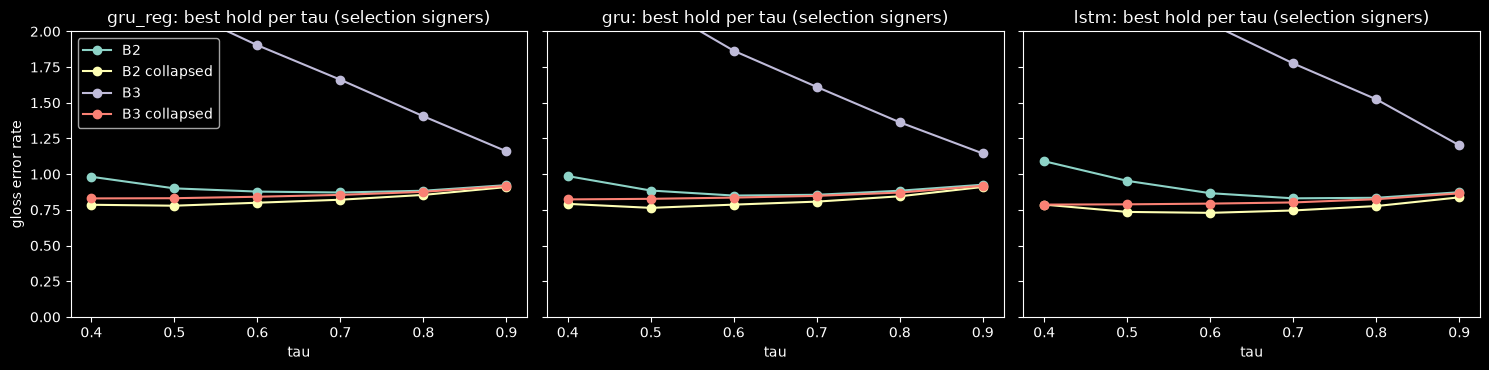

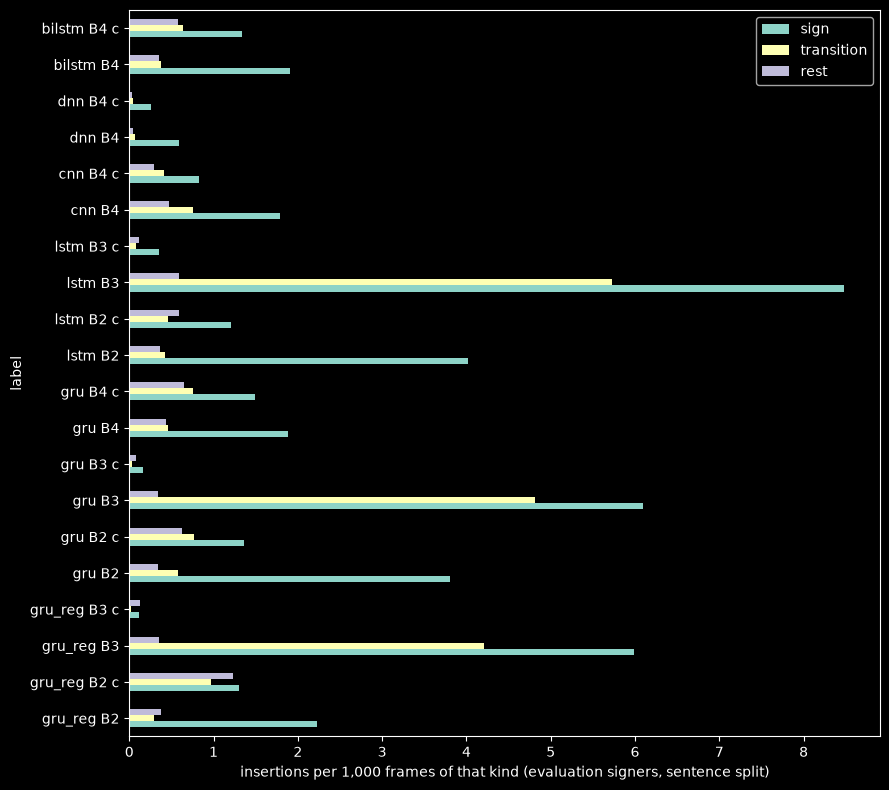

In [11]:
# ============================================================
# Figures: GER vs tau (B2/B3), and where insertions land
# ============================================================
fig, axes = plt.subplots(1, len(CONFIG["reset_decode"]["models"]), figsize=(5 * len(CONFIG["reset_decode"]["models"]), 3.8),
                         sharey=True, squeeze=False)
for ax, name in zip(axes[0], CONFIG["reset_decode"]["models"]):
    sw = pd.DataFrame(json.loads((OUT / f"sweep_{name}_reset.json").read_text()))
    for (mode, c), grp in sw.groupby(["mode", "collapse"]):
        best = grp.loc[grp.groupby("tau")["ger"].idxmin()]
        ax.plot(best["tau"], best["ger"], marker="o", label=f"{mode}{' collapsed' if c else ''}")
    ax.set_title(f"{name}: best hold per tau (selection signers)")
    ax.set_xlabel("tau")
    ax.set_ylim(0, 2)
axes[0][0].set_ylabel("gloss error rate")
axes[0][0].legend()
fig.tight_layout()
fig.savefig(ASSETS / "ger_vs_tau.png", dpi=110)
plt.show()

res = pd.json_normalize(json.loads((OUT / "final.json").read_text())["results"])
sub = res[(res.split == "sentence") & (res.frames == "with-null") & (res["mode"] != "B1")].copy()
sub["label"] = sub["model"] + " " + sub["mode"] + np.where(sub["collapse"], " c", "")
cols = [c for c in ("ins_per_1k_frames.sign", "ins_per_1k_frames.transition", "ins_per_1k_frames.rest") if c in sub]
ax = sub.set_index("label")[cols].rename(columns=lambda c: c.split(".")[-1]).plot.barh(figsize=(9, 0.35 * len(sub) + 1))
ax.set_xlabel("insertions per 1,000 frames of that kind (evaluation signers, sentence split)")
plt.tight_layout()
plt.savefig(ASSETS / "insertions_by_kind.png", dpi=110)
plt.show()